#**Women's Clothing E-Commerce Reviews**
##Sentiment Analysis + Exploratory Data Analysis
### Model: cardiffnlp/twitter-roberta-base-sentiment

### What this notebook covers:
1. Load and inspect the dataset
2. Run a **Transformer-based** sentiment classification model on 2,000 rows (RoBERTa)
3. Exploratory Data Analysis — all columns + new sentiment columns
4. **Q1:** Products with most positive and most negative sentiment
5. **Q2:** Sentiment by Division, Department, and Class
6. **Q3:** Correlation between categories and sentiment score

In [39]:
# Install / upgrade Hugging Face Transformers
!pip install transformers torch -q

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


##Style Configuration

**What this does:**  
Sets the visual theme for all charts.

In [41]:
BRAND_PALETTE = {
    'Positive': '#4CAF82',
    'Neutral':  '#F4A828',
    'Negative': '#E05C5C',
    'bg':       '#FFFFFF',
    'text':     '#2C2C2C',
    'grid':     '#E0DDD8',
    'accent':   '#7B68EE',
}

DIV_COLORS  = ['#7B68EE', '#4CAF82', '#F4A828']
DEPT_COLORS = ['#7B68EE', '#4CAF82', '#F4A828', '#E05C5C', '#5BC0DE', '#A0A0A0']

plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'axes.facecolor':   BRAND_PALETTE['bg'],
    'figure.facecolor': BRAND_PALETTE['bg'],
    'axes.edgecolor':   BRAND_PALETTE['grid'],
    'axes.grid':        True,
    'grid.color':       BRAND_PALETTE['grid'],
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'text.color':       BRAND_PALETTE['text'],
    'xtick.color':      BRAND_PALETTE['text'],
    'ytick.color':      BRAND_PALETTE['text'],
    'axes.labelcolor':  BRAND_PALETTE['text'],
})

print('Style configured!')

Style configured!


##Step 1 — Mount Google Drive & Load the Dataset

**What this does:**  
Mounts your Google Drive so we can access the CSV file stored there. Then we unzip the archive and load the CSV into a pandas DataFrame.

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import zipfile

zip_file_path  = r'/content/drive/MyDrive/Python Bootcamp Uplift/Colab Notebooks/Dataset_WomensECommerce/archive.zip'
file_folder_path = r'/content/drive/MyDrive/Python Bootcamp Uplift/Colab Notebooks/Dataset_WomensECommerce/'

with zipfile.ZipFile(zip_file_path) as zip_ref:
    zip_ref.extractall(file_folder_path)

print('Archive extracted')

Archive extracted


In [44]:
file_path = r'/content/drive/MyDrive/Python Bootcamp Uplift/Colab Notebooks/Dataset_WomensECommerce/Womens Clothing E-Commerce Reviews.csv'

# Load the CSV into a pandas DataFrame
df_raw = pd.read_csv(file_path)

# Rename the messy first column
df_raw.rename(columns={'Unnamed: 0': 'Row Index'}, inplace=True)

print(f'Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'\nColumn names and data types:')
print(df_raw.dtypes)
print(f'\nMissing values per column:')
print(df_raw.isnull().sum())

Dataset shape: 23,486 rows × 11 columns

Column names and data types:
Row Index                   int64
Clothing ID                 int64
Age                         int64
Title                      object
Review Text                object
Rating                      int64
Recommended IND             int64
Positive Feedback Count     int64
Division Name              object
Department Name            object
Class Name                 object
dtype: object

Missing values per column:
Row Index                     0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


In [45]:
# Preview the first 5 rows
df_raw.head()

,Row Index,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


##Step 2 — Load the RoBERTa Model

**What this does:**  
**cardiffnlp/twitter-roberta-base-sentiment** is a RoBERTa model fine-tuned on ~58 million tweets. It was trained specifically to understand the kind of informal, opinion-heavy language that also shows up in product reviews.

The **pipeline()** function from Hugging Face wraps the model in a simple interface — you give it text, it gives you back a sentiment label and a confidence score. Think of it as the professional-grade upgrade from VADER.

**Note:** The first run downloads the model weights (~500MB). This takes 1–2 minutes. Subsequent runs in the same session are instant because the model is cached.

In [46]:
# Define the model name
sentiment_model = "cardiffnlp/twitter-roberta-base-sentiment"

# Load the pipeline — downloads model on first run
classifier = pipeline(
    "sentiment-analysis",
    model=sentiment_model,
    tokenizer=sentiment_model,
    top_k=None,          # Return scores for ALL 3 labels (not just the top one)
    truncation=True,     # Reviews longer than 512 tokens get cut off automatically
    max_length=512       # RoBERTa's hard token limit
)

print('    RoBERTa model loaded and ready!')
print(f'   Model: {sentiment_model}')
print(f'   Labels: LABEL_0 = Negative | LABEL_1 = Neutral | LABEL_2 = Positive')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    RoBERTa model loaded and ready!
   Model: cardiffnlp/twitter-roberta-base-sentiment
   Labels: LABEL_0 = Negative | LABEL_1 = Neutral | LABEL_2 = Positive


## Step 3 — Run Sentiment Classification (2,000 rows)

**What this does:**  
We run the classifier on 2,000 reviews in **batches of 32** — meaning 32 reviews are processed at once instead of one at a time. Batching is significantly faster because the GPU (if available) can process multiple inputs in parallel.

For each review, the model returns **3 scores** — one probability for each label. The three probabilities always add up to 1.0 (100%). We extract them individually into their own columns:

| New Column | Meaning |
|---|---|
| Roberta Pos Score | Probability the review is Positive (0–1) |
| Roberta Neu Score | Probability the review is Neutral (0–1) |
| Roberta Neg Score | Probability the review is Negative (0–1) |
| Roberta Score | `Pos Score − Neg Score` → ranges from **-1 to +1**, like VADER's compound |
| Sentiment Label | The label with the highest probability |

In [47]:
# Step 3A: Filter to rows with review text, take first 2,000
df = df_raw.dropna(subset=['Review Text']).head(2000).copy()
print(f'Working sample: {len(df):,} rows')

# Step 3B: Extract the review texts as a plain Python list
# (the classifier expects a list, not a pandas Series)
texts = df['Review Text'].astype(str).tolist()

# Step 3C: Run the model in batches
# top_k=None means we get back all 3 label scores per review
# batch_size=32 processes 32 reviews at a time — faster than one-by-one
print('\n Running RoBERTa classifier... (this may take 2–5 minutes)')
results = classifier(texts, batch_size=32)
print('Classification complete!')

# Step 3D: Parse results into a helper DataFrame
# Each result is a list of 3 dicts: [{'label': 'LABEL_0', 'score': 0.02}, ...]
# We convert the list into a dict keyed by label for easy lookup
label_map = {'LABEL_0': 'Negative', 'LABEL_1': 'Neutral', 'LABEL_2': 'Positive'}

pos_scores, neu_scores, neg_scores = [], [], []

for result in results:
    # result is a list of 3 dicts — turn into {label: score}
    score_dict = {item['label']: item['score'] for item in result}
    pos_scores.append(score_dict.get('LABEL_2', 0.0))   # LABEL_2 = Positive
    neu_scores.append(score_dict.get('LABEL_1', 0.0))   # LABEL_1 = Neutral
    neg_scores.append(score_dict.get('LABEL_0', 0.0))   # LABEL_0 = Negative

# Step 3E: Add the new columns to the DataFrame
df['Roberta Pos Score'] = pos_scores
df['Roberta Neu Score'] = neu_scores
df['Roberta Neg Score'] = neg_scores

# Roberta Score: analogous to VADER compound — ranges -1 to +1
df['Roberta Score'] = df['Roberta Pos Score'] - df['Roberta Neg Score']

# Sentiment Label: pick the class with the highest probability
def get_label(pos, neu, neg):
    scores = {'Positive': pos, 'Neutral': neu, 'Negative': neg}
    return max(scores, key=scores.get)

df['Sentiment Label'] = df.apply(
    lambda row: get_label(row['Roberta Pos Score'],
                          row['Roberta Neu Score'],
                          row['Roberta Neg Score']), axis=1
)

print('\nSentiment breakdown:')
print(df['Sentiment Label'].value_counts())
print(f'\nRoberta Score statistics:')
print(df['Roberta Score'].describe().round(4))

Working sample: 2,000 rows

 Running RoBERTa classifier... (this may take 2–5 minutes)
Classification complete!

Sentiment breakdown:
Sentiment Label
Positive    1658
Negative     231
Neutral      111
Name: count, dtype: int64

Roberta Score statistics:
count    2000.0000
mean        0.6649
std         0.5282
min        -0.9712
25%         0.5961
50%         0.9485
75%         0.9809
max         0.9919
Name: Roberta Score, dtype: float64


In [48]:
# Preview the DataFrame with the new sentiment columns added
df[['Clothing ID', 'Review Text', 'Rating',
    'Roberta Score', 'Roberta Pos Score',
    'Roberta Neg Score', 'Roberta Neu Score',
    'Sentiment Label']].head(10)

,Clothing ID,Review Text,Rating,Roberta Score,Roberta Pos Score,Roberta Neg Score,Roberta Neu Score,Sentiment Label
0,767,Absolutely wonderful - silky and sexy and comf...,4,0.984935,0.987180,0.002245,0.010576,Positive
1,1080,Love this dress! it's sooo pretty. i happene...,5,0.989346,0.990955,0.001609,0.007436,Positive
2,1077,I had such high hopes for this dress and reall...,3,-0.113747,0.253056,0.366804,0.380140,Neutral
3,1049,"I love, love, love this jumpsuit. it's fun, fl...",5,0.990885,0.993131,0.002247,0.004622,Positive
4,847,This shirt is very flattering to all due to th...,5,0.990790,0.992028,0.001239,0.006733,Positive
5,1080,"I love tracy reese dresses, but this one is no...",2,0.375451,0.545943,0.170491,0.283566,Positive
6,858,I aded this in my basket at hte last mintue to...,5,0.916164,0.922028,0.005863,0.072109,Positive
7,858,"I ordered this in carbon for store pick up, an...",4,0.839429,0.848489,0.009060,0.142452,Positive
8,1077,I love this dress. i usually get an xs but it ...,5,0.985749,0.987146,0.001397,0.011456,Positive
9,1077,"I'm 5""5' and 125 lbs. i ordered the s petite t...",5,0.965982,0.969403,0.003420,0.027177,Positive


## Step 4 — EDA Overview Dashboard (Fig 1)

**What this does:**  
A 9-panel snapshot of all columns — original and newly created. The structure is identical to the VADER version, but **Panel 2** now shows the **Roberta Score** distribution instead of the VADER compound score.

Key difference to watch: RoBERTa tends to produce **more spread-out distributions** than VADER. VADER often pushes scores toward the extremes (very near +1 or -1); RoBERTa gives more nuanced mid-range probabilities.

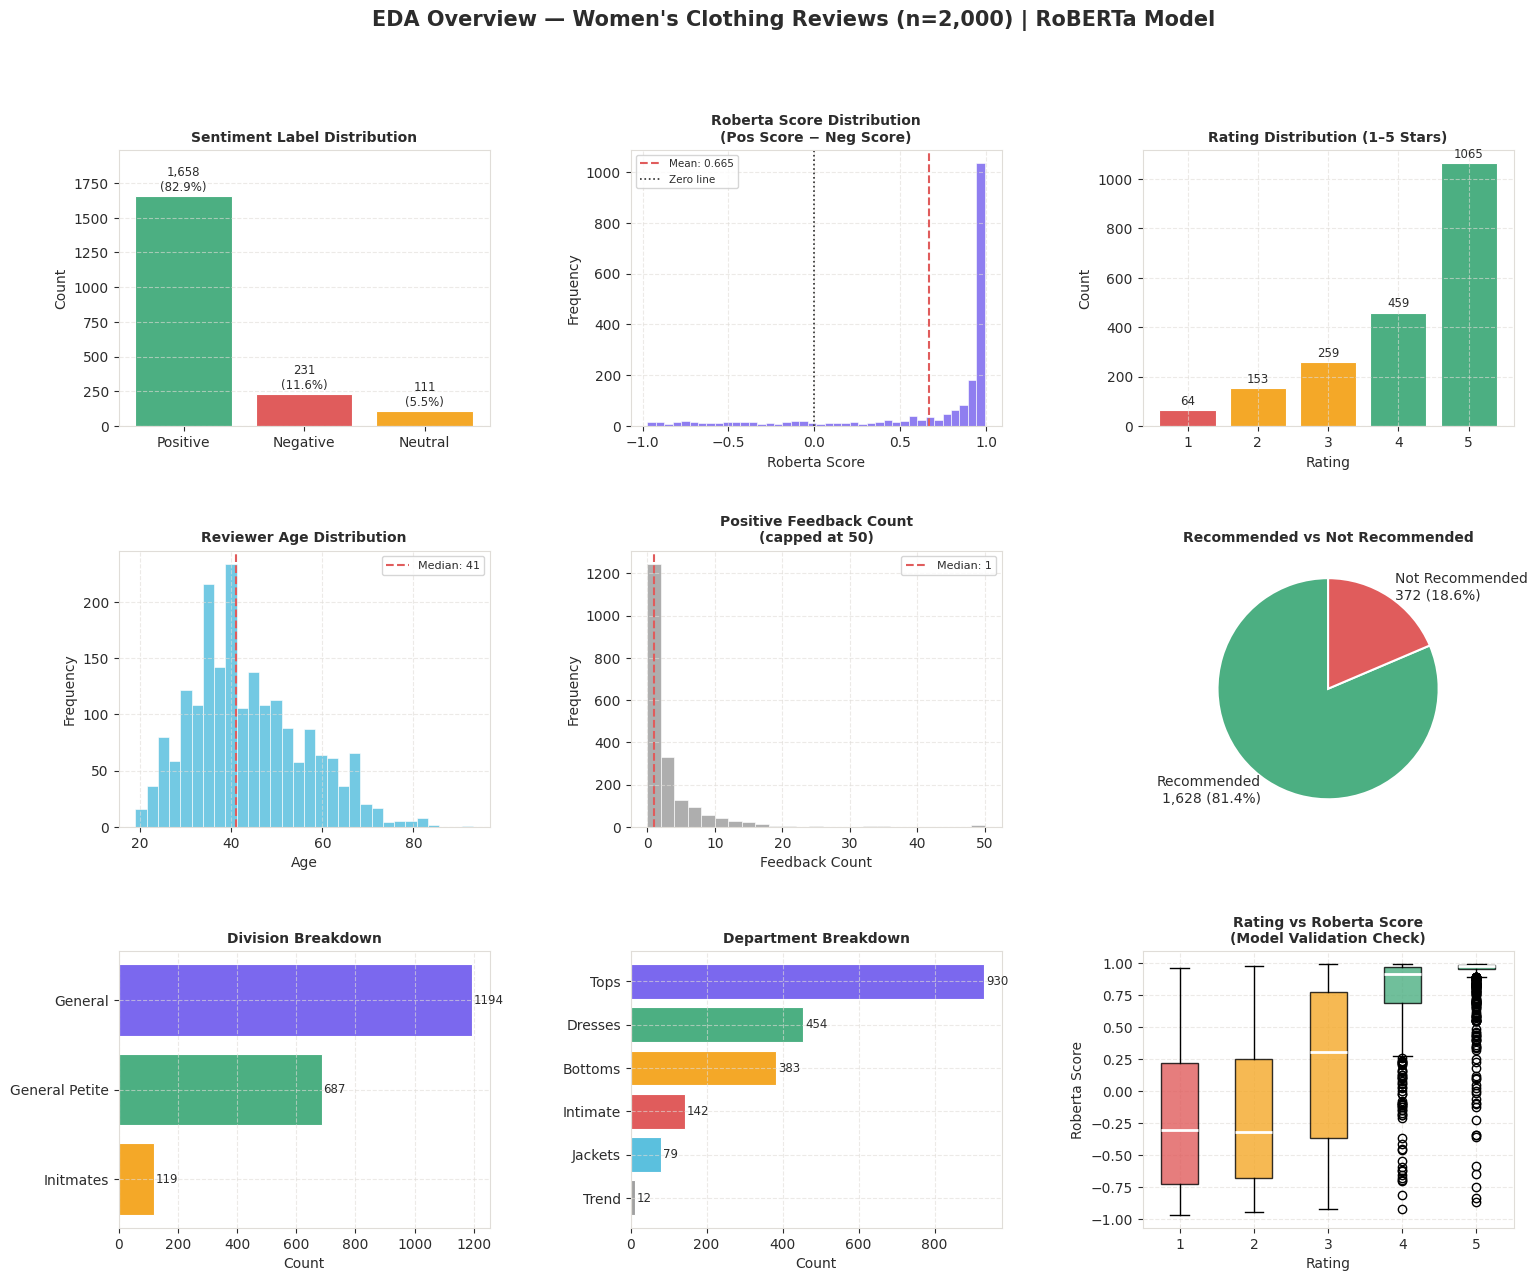

Fig 1 — EDA Overview


In [49]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(BRAND_PALETTE['bg'])
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle("EDA Overview — Women's Clothing Reviews (n=2,000) | RoBERTa Model",
             fontsize=15, fontweight='bold', y=0.98, color=BRAND_PALETTE['text'])

# ── Panel 1: Sentiment Label Counts ──────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
sent_counts = df['Sentiment Label'].value_counts()
colors = [BRAND_PALETTE[s] for s in sent_counts.index]
bars = ax1.bar(sent_counts.index, sent_counts.values, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, sent_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=8.5)
ax1.set_title('Sentiment Label Distribution', fontweight='bold', fontsize=10)
ax1.set_ylabel('Count')
ax1.set_ylim(0, sent_counts.max() * 1.2)
ax1.grid(axis='x', alpha=0)

# ── Panel 2: Roberta Score Histogram ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df['Roberta Score'], bins=40, color=BRAND_PALETTE['accent'],
         edgecolor='white', linewidth=0.5, alpha=0.85)
ax2.axvline(df['Roberta Score'].mean(), color=BRAND_PALETTE['Negative'],
            linestyle='--', linewidth=1.5, label=f"Mean: {df['Roberta Score'].mean():.3f}")
ax2.axvline(0, color=BRAND_PALETTE['text'], linestyle=':', linewidth=1.2, label='Zero line')
ax2.set_title('Roberta Score Distribution\n(Pos Score − Neg Score)', fontweight='bold', fontsize=10)
ax2.set_xlabel('Roberta Score')
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=7.5)

# ── Panel 3: Rating Distribution ─────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
rating_counts = df['Rating'].value_counts().sort_index()
bar_colors = ['#E05C5C','#F4A828','#F4A828','#4CAF82','#4CAF82']
ax3.bar(rating_counts.index, rating_counts.values, color=bar_colors, edgecolor='white', linewidth=0.8)
for i, (idx, val) in enumerate(rating_counts.items()):
    ax3.text(idx, val + 10, str(val), ha='center', va='bottom', fontsize=8.5)
ax3.set_title('Rating Distribution (1–5 Stars)', fontweight='bold', fontsize=10)
ax3.set_xlabel('Rating')
ax3.set_ylabel('Count')
ax3.set_xticks([1, 2, 3, 4, 5])

# ── Panel 4: Age Distribution ─────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df['Age'], bins=30, color='#5BC0DE', edgecolor='white', linewidth=0.5, alpha=0.85)
ax4.axvline(df['Age'].median(), color=BRAND_PALETTE['Negative'],
            linestyle='--', linewidth=1.5, label=f"Median: {df['Age'].median():.0f}")
ax4.set_title('Reviewer Age Distribution', fontweight='bold', fontsize=10)
ax4.set_xlabel('Age')
ax4.set_ylabel('Frequency')
ax4.legend(fontsize=8)

# ── Panel 5: Positive Feedback Count ──────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
pf_clipped = df['Positive Feedback Count'].clip(upper=50)
ax5.hist(pf_clipped, bins=25, color='#A0A0A0', edgecolor='white', linewidth=0.5, alpha=0.85)
median_pf = df['Positive Feedback Count'].median()
ax5.axvline(median_pf, color=BRAND_PALETTE['Negative'],
            linestyle='--', linewidth=1.5, label=f'Median: {median_pf:.0f}')
ax5.set_title('Positive Feedback Count\n(capped at 50)', fontweight='bold', fontsize=10)
ax5.set_xlabel('Feedback Count')
ax5.set_ylabel('Frequency')
ax5.legend(fontsize=8)

# ── Panel 6: Recommended Pie Chart ────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
rec_counts = df['Recommended IND'].map({1: 'Recommended', 0: 'Not Recommended'}).value_counts()
ax6.pie(rec_counts.values,
        labels=[f"{l}\n{v:,} ({v/len(df)*100:.1f}%)" for l, v in zip(rec_counts.index, rec_counts.values)],
        colors=[BRAND_PALETTE['Positive'], BRAND_PALETTE['Negative']],
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax6.set_title('Recommended vs Not Recommended', fontweight='bold', fontsize=10)

# ── Panel 7: Division Breakdown ───────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
div_counts = df['Division Name'].value_counts()
ax7.barh(div_counts.index, div_counts.values,
         color=DIV_COLORS[:len(div_counts)], edgecolor='white', linewidth=0.8)
for i, val in enumerate(div_counts.values):
    ax7.text(val + 5, i, str(val), va='center', fontsize=8.5)
ax7.set_title('Division Breakdown', fontweight='bold', fontsize=10)
ax7.set_xlabel('Count')
ax7.invert_yaxis()

# ── Panel 8: Department Breakdown ─────────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
dept_counts = df['Department Name'].value_counts()
ax8.barh(dept_counts.index, dept_counts.values,
         color=DEPT_COLORS[:len(dept_counts)], edgecolor='white', linewidth=0.8)
for i, val in enumerate(dept_counts.values):
    ax8.text(val + 5, i, str(val), va='center', fontsize=8.5)
ax8.set_title('Department Breakdown', fontweight='bold', fontsize=10)
ax8.set_xlabel('Count')
ax8.invert_yaxis()

# ── Panel 9: Rating vs Roberta Score (Boxplot) ────────────────
# Boxplot shows: if higher star ratings produce higher Roberta Scores
# This is our model validation check — they should align!
ax9 = fig.add_subplot(gs[2, 2])
rating_groups = [df[df['Rating'] == r]['Roberta Score'].values for r in sorted(df['Rating'].unique())]
bp = ax9.boxplot(rating_groups, patch_artist=True, widths=0.5,
                 medianprops={'color': 'white', 'linewidth': 2})
for patch, c in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.8)
ax9.set_xticklabels([str(r) for r in sorted(df['Rating'].unique())])
ax9.set_title('Rating vs Roberta Score\n(Model Validation Check)', fontweight='bold', fontsize=10)
ax9.set_xlabel('Rating')
ax9.set_ylabel('Roberta Score')

plt.savefig('fig1_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 1 — EDA Overview')

## Step 5 — Q1: Products with Most Positive & Negative Sentiment (Fig 2)

**What this does:**  
Groups all reviews by **Clothing ID** and computes the **average Roberta Score** per product. Only products with **≥5 reviews** are included for statistical reliability.

Because RoBERTa sometimes gives a more conservative score than VADER (less extreme), you may see the rankings shift slightly compared to the VADER version. That's expected — a deeper model picks up on nuance VADER misses.

In [50]:
# Group by Clothing ID and compute summary stats
# Note: We now use 'Roberta Score' instead of 'Compound Score'
product_stats = df.groupby('Clothing ID').agg(
    Review_Count  = ('Roberta Score', 'count'),
    Avg_Score     = ('Roberta Score', 'mean'),
    Pct_Positive  = ('Sentiment Label', lambda x: (x == 'Positive').mean() * 100),
    Pct_Negative  = ('Sentiment Label', lambda x: (x == 'Negative').mean() * 100),
    Avg_Rating    = ('Rating', 'mean'),
).reset_index()

# Filter: only products with 5+ reviews (more reliable)
product_min = product_stats[product_stats['Review_Count'] >= 5]

# Top 10 most positive and most negative
top_pos = product_min.nlargest(10, 'Avg_Score')
top_neg = product_min.nsmallest(10, 'Avg_Score')

print(f'Products with ≥5 reviews: {len(product_min)}')
print(f'\nTop 5 Most Positive Products:')
print(top_pos[['Clothing ID', 'Review_Count', 'Avg_Score', 'Avg_Rating']].head().to_string(index=False))
print(f'\nTop 5 Most Negative Products:')
print(top_neg[['Clothing ID', 'Review_Count', 'Avg_Score', 'Avg_Rating']].head().to_string(index=False))

Products with ≥5 reviews: 92

Top 5 Most Positive Products:
 Clothing ID  Review_Count  Avg_Score  Avg_Rating
         745             5   0.977099    4.800000
         940             5   0.964555    4.800000
         985             6   0.955476    4.666667
         720             5   0.948234    4.800000
         964            10   0.944337    5.000000

Top 5 Most Negative Products:
 Clothing ID  Review_Count  Avg_Score  Avg_Rating
         946             6  -0.036213    2.000000
        1055             5   0.027104    3.000000
        1086             6   0.215185    3.833333
        1082             7   0.226288    3.428571
        1077            11   0.311564    3.727273


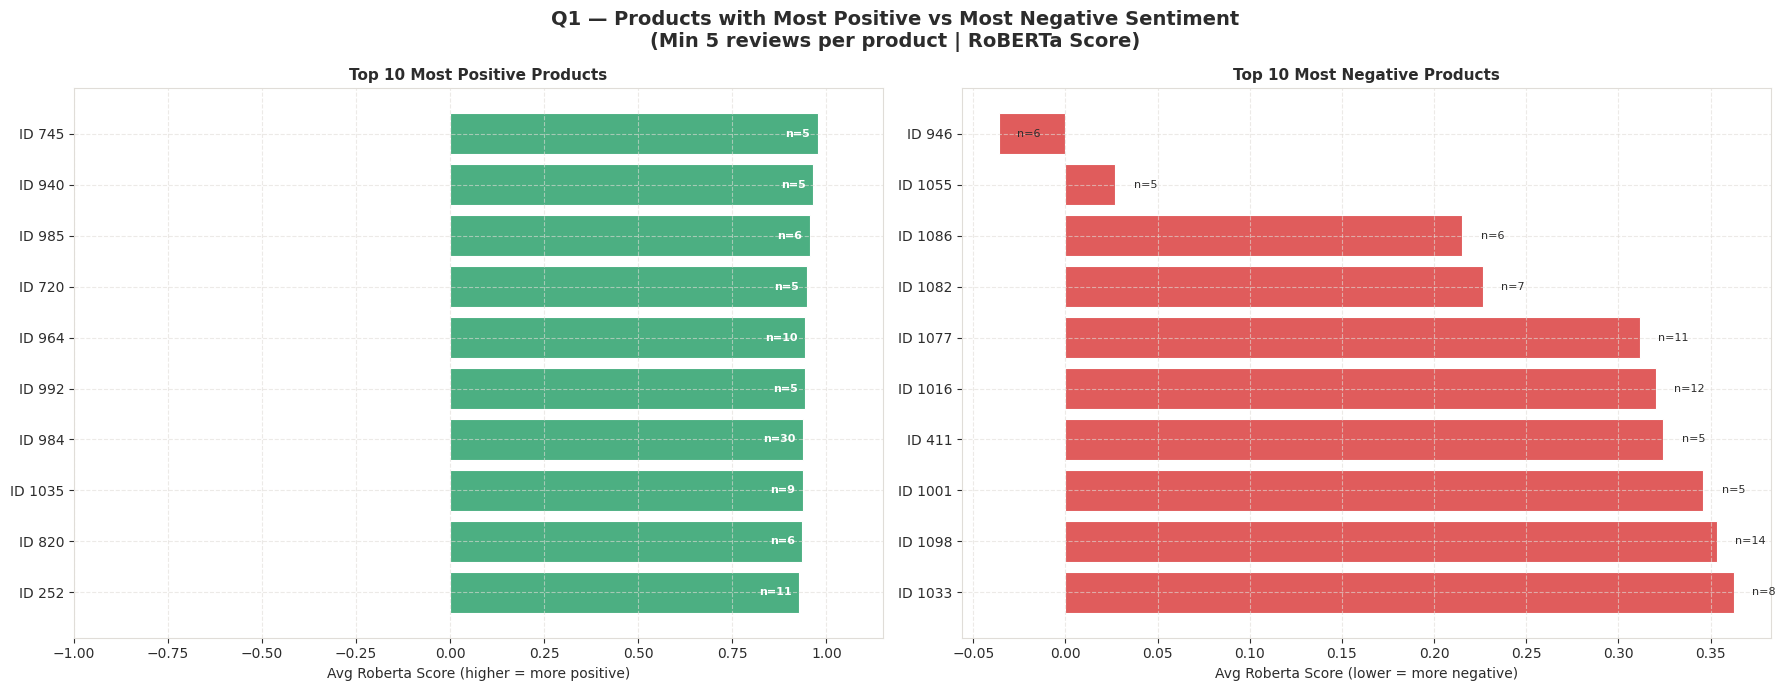

Fig 2 — Product Sentiment


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(BRAND_PALETTE['bg'])
fig.suptitle('Q1 — Products with Most Positive vs Most Negative Sentiment\n(Min 5 reviews per product | RoBERTa Score)',
             fontsize=14, fontweight='bold', color=BRAND_PALETTE['text'])

# Left: Most Positive
ax = axes[0]
ax.set_facecolor(BRAND_PALETTE['bg'])
bars = ax.barh([f"ID {int(x)}" for x in top_pos['Clothing ID']],
               top_pos['Avg_Score'],
               color=BRAND_PALETTE['Positive'], edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, top_pos['Review_Count']):
    ax.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2,
            f'n={int(count)}', va='center', ha='right', color='white', fontsize=8, fontweight='bold')
ax.set_title('Top 10 Most Positive Products', fontweight='bold', fontsize=11)
ax.set_xlabel('Avg Roberta Score (higher = more positive)')
ax.set_xlim(-1, 1.15)
ax.invert_yaxis()

# Right: Most Negative
ax = axes[1]
ax.set_facecolor(BRAND_PALETTE['bg'])
bars = ax.barh([f"ID {int(x)}" for x in top_neg['Clothing ID']],
               top_neg['Avg_Score'],
               color=BRAND_PALETTE['Negative'], edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, top_neg['Review_Count']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'n={int(count)}', va='center', ha='left', color=BRAND_PALETTE['text'], fontsize=8)
ax.set_title('Top 10 Most Negative Products', fontweight='bold', fontsize=11)
ax.set_xlabel('Avg Roberta Score (lower = more negative)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('fig2_product_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 2 — Product Sentiment')

##Step 6 — Q2: Sentiment by Division, Department & Class (Fig 3)

**What this does:**  
Repeats the groupby analysis for Division, Department, and Class. Two chart types per level:
- **Left:** Average Roberta Score per category
- **Right:** % breakdown of Positive / Neutral / Negative per category

The reusable function make_category_sentiment() is updated to reference **Roberta Score** instead of **Compound Score**.

In [52]:
# Reusable function: computes sentiment stats for any categorical column
# Updated to use 'Roberta Score' as the numeric sentiment measure
def make_category_sentiment(col):
    grp = df.dropna(subset=[col]).groupby(col).agg(
        Count        = ('Roberta Score', 'count'),
        Avg_Score    = ('Roberta Score', 'mean'),
        Pct_Positive = ('Sentiment Label', lambda x: (x == 'Positive').mean() * 100),
        Pct_Negative = ('Sentiment Label', lambda x: (x == 'Negative').mean() * 100),
        Pct_Neutral  = ('Sentiment Label', lambda x: (x == 'Neutral').mean() * 100),
    ).reset_index().sort_values('Avg_Score', ascending=True)
    return grp

div_df   = make_category_sentiment('Division Name')
dept_df  = make_category_sentiment('Department Name')
class_df = make_category_sentiment('Class Name')

print('Division Sentiment (sorted by Avg Roberta Score):')
print(div_df[['Division Name', 'Count', 'Avg_Score', 'Pct_Positive', 'Pct_Negative']].to_string(index=False))
print('\nDepartment Sentiment:')
print(dept_df[['Department Name', 'Count', 'Avg_Score', 'Pct_Positive', 'Pct_Negative']].to_string(index=False))

Division Sentiment (sorted by Avg Roberta Score):
 Division Name  Count  Avg_Score  Pct_Positive  Pct_Negative
       General   1194   0.656280     82.830821     11.892797
General Petite    687   0.677005     83.114993     11.062591
     Initmates    119   0.681397     82.352941     10.924370

Department Sentiment:
Department Name  Count  Avg_Score  Pct_Positive  Pct_Negative
          Trend     12   0.554820     75.000000     25.000000
        Dresses    454   0.598471     78.854626     13.876652
           Tops    930   0.671338     83.333333     11.397849
        Bottoms    383   0.684920     84.595300     10.704961
       Intimate    142   0.687891     82.394366     10.563380
        Jackets     79   0.849031     94.936709      3.797468


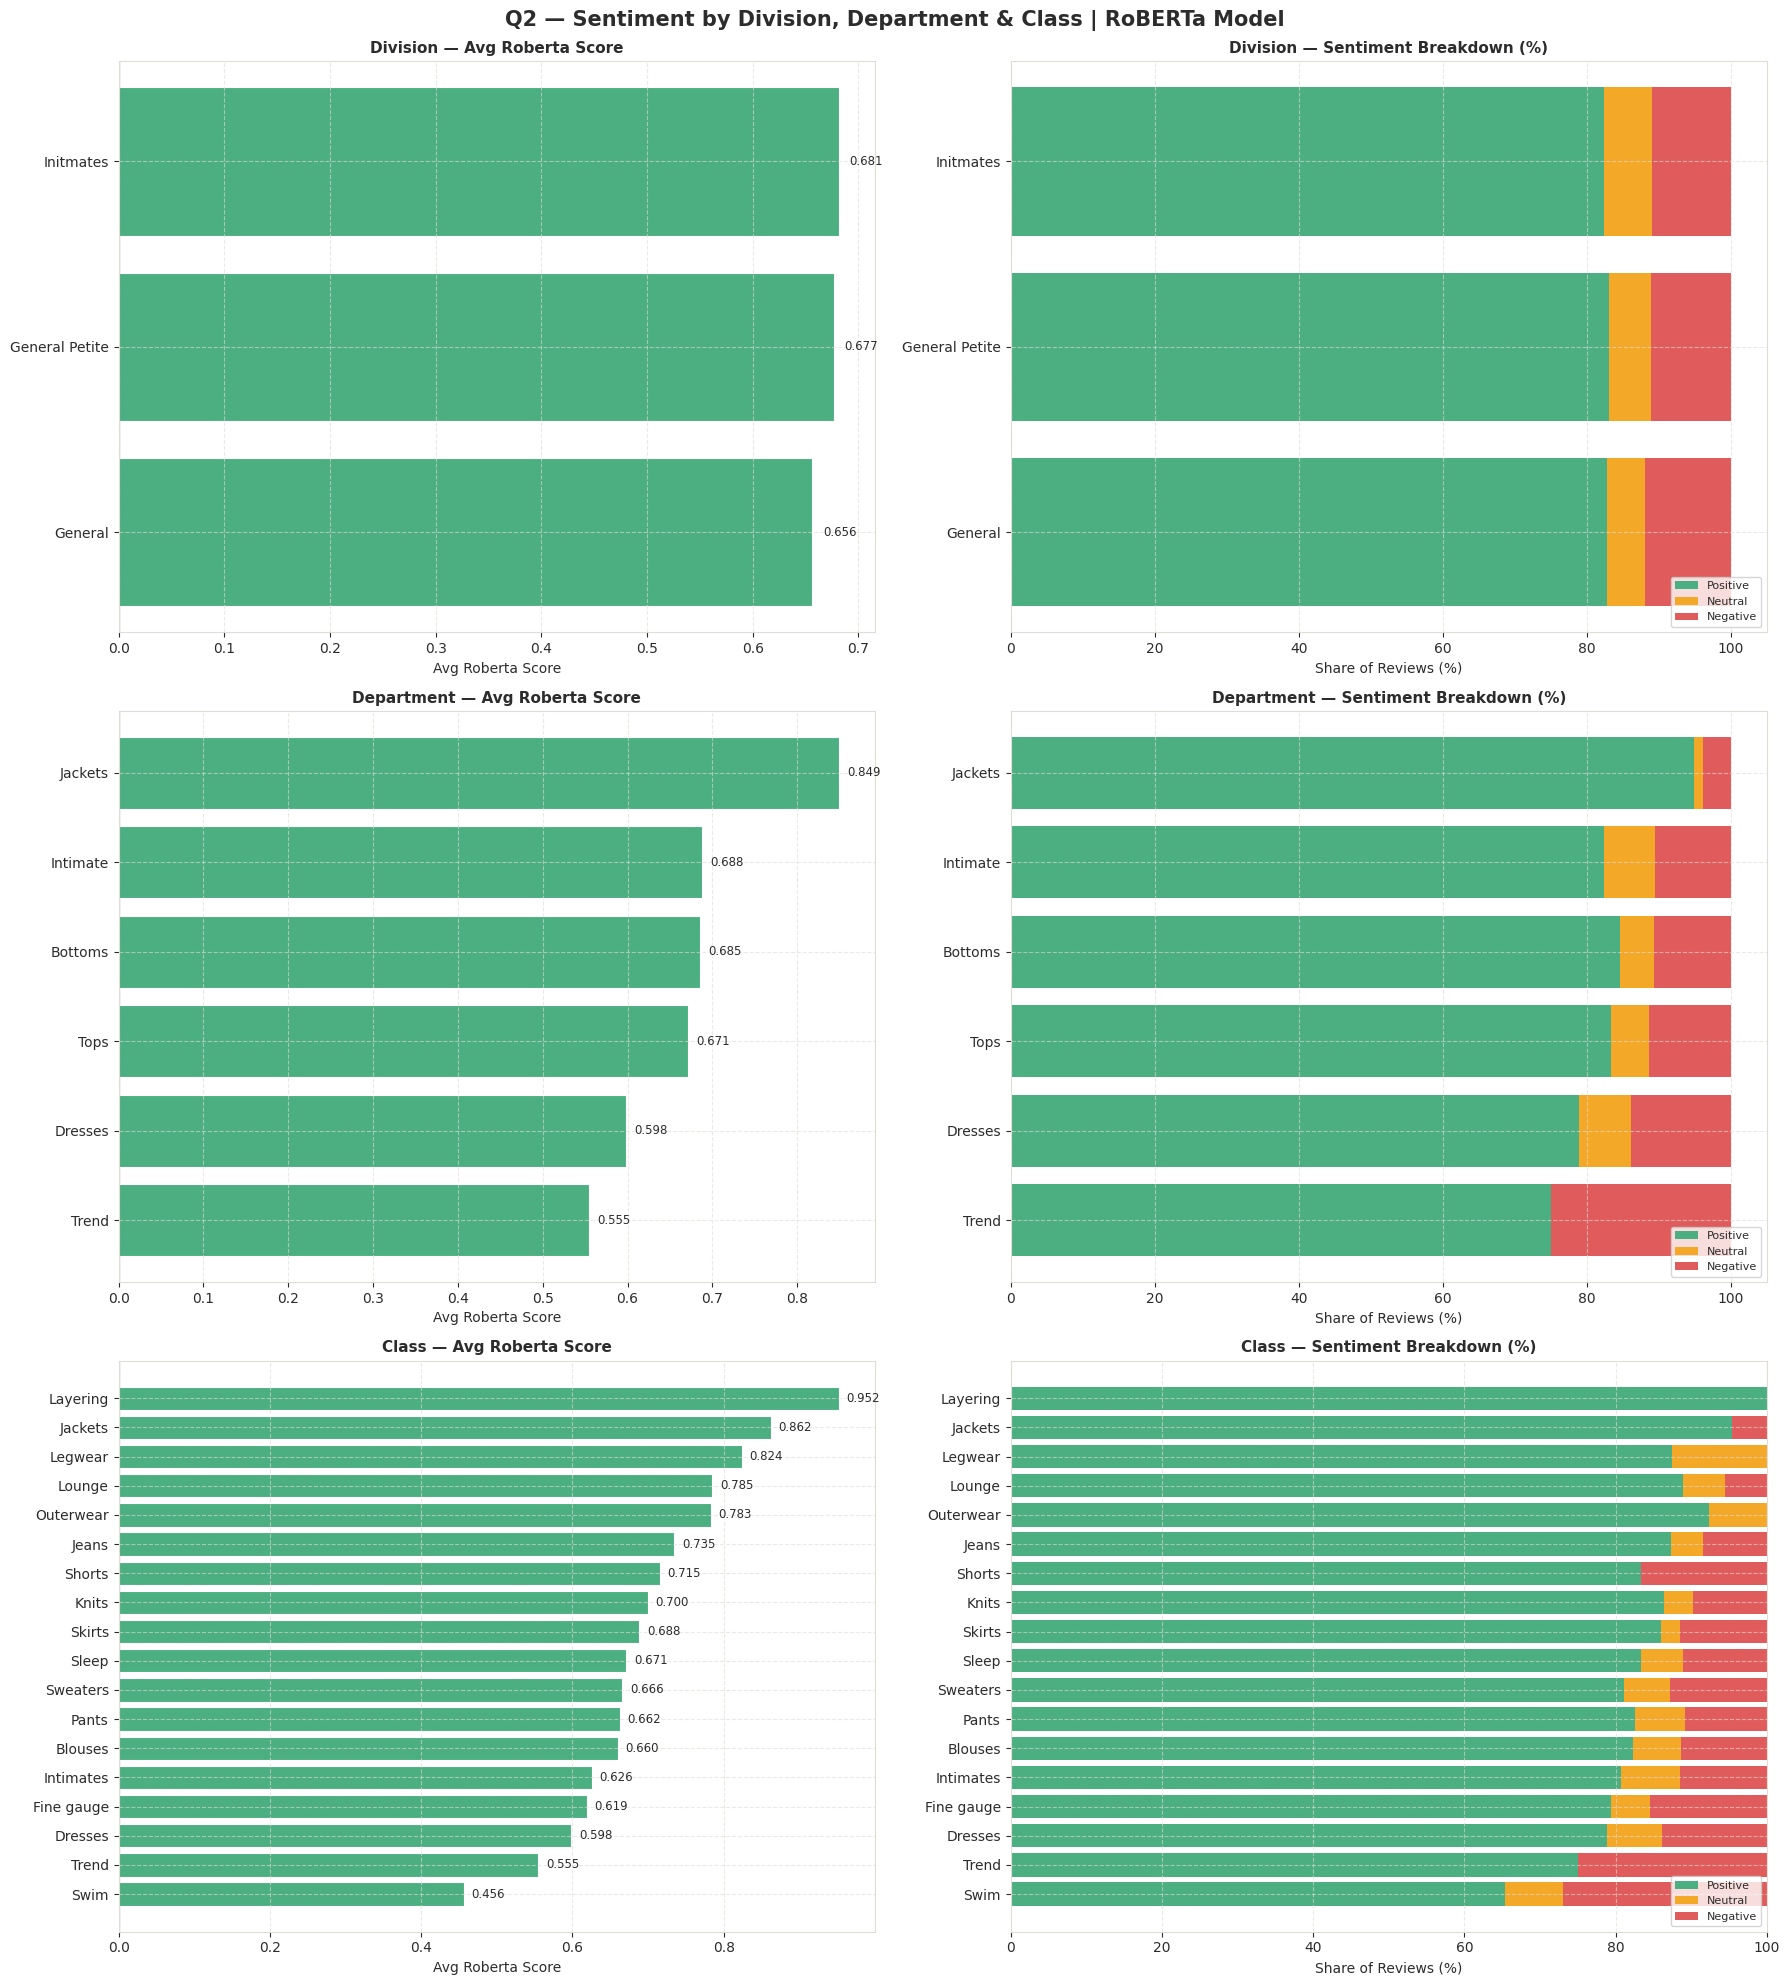

Fig 3 — Division / Department / Class Sentiment


In [53]:
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.patch.set_facecolor(BRAND_PALETTE['bg'])
fig.suptitle('Q2 — Sentiment by Division, Department & Class | RoBERTa Model',
             fontsize=15, fontweight='bold', color=BRAND_PALETTE['text'], y=0.99)

def plot_avg_score(ax, data, col, title):
    """Bar chart: average Roberta Score per category."""
    # Color logic: negative score = red, positive = green
    colors = [BRAND_PALETTE['Negative'] if v < 0 else BRAND_PALETTE['Positive']
              for v in data['Avg_Score']]
    bars = ax.barh(data[col], data['Avg_Score'], color=colors, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, data['Avg_Score']):
        x_pos = v + 0.01 if v >= 0 else v - 0.01
        ha = 'left' if v >= 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', ha=ha, fontsize=8.5)
    ax.axvline(0, color=BRAND_PALETTE['text'], linewidth=0.8, linestyle='-')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Avg Roberta Score')
    ax.set_facecolor(BRAND_PALETTE['bg'])

def plot_stacked_pct(ax, data, col, title):
    """Stacked bar chart: % Positive / Neutral / Negative per category."""
    ax.set_facecolor(BRAND_PALETTE['bg'])
    x = range(len(data))
    ax.barh(list(x), data['Pct_Positive'], color=BRAND_PALETTE['Positive'], label='Positive')
    ax.barh(list(x), data['Pct_Neutral'],
            left=data['Pct_Positive'], color=BRAND_PALETTE['Neutral'], label='Neutral')
    ax.barh(list(x), data['Pct_Negative'],
            left=data['Pct_Positive'] + data['Pct_Neutral'],
            color=BRAND_PALETTE['Negative'], label='Negative')
    ax.set_yticks(list(x))
    ax.set_yticklabels(data[col])
    ax.set_xlabel('Share of Reviews (%)')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(loc='lower right', fontsize=8)

# Row 1: Division
plot_avg_score   (axes[0,0], div_df,   'Division Name',   'Division — Avg Roberta Score')
plot_stacked_pct (axes[0,1], div_df,   'Division Name',   'Division — Sentiment Breakdown (%)')

# Row 2: Department
plot_avg_score   (axes[1,0], dept_df,  'Department Name', 'Department — Avg Roberta Score')
plot_stacked_pct (axes[1,1], dept_df,  'Department Name', 'Department — Sentiment Breakdown (%)')

# Row 3: Class
plot_avg_score   (axes[2,0], class_df, 'Class Name',      'Class — Avg Roberta Score')
plot_stacked_pct (axes[2,1], class_df, 'Class Name',      'Class — Sentiment Breakdown (%)')

plt.tight_layout()
plt.savefig('fig3_division_dept_class_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 3 — Division / Department / Class Sentiment')

## 🔗 Step 7 — Q3: Correlation Analysis (Fig 4)

**What this does:**  
Examines the relationships between all numeric features and the **Roberta Score**.

Compared to the VADER version, the RoBERTa correlation matrix includes the **three raw probability columns** **(Roberta Pos Score, Roberta Neg Score, Roberta Neu Score)** instead of VADER's **pos, neg, neu**. These are more meaningful because they reflect a model that read the full sentence in context rather than just counting sentiment words.

> **Encoding reminder:** Division, Department, and Class are still text. We use **.cat.codes** for label encoding before computing correlations, exactly as before.

In [54]:
# Encode categorical columns as numbers for correlation computation
df_corr = df.copy()
df_corr['Division_Enc']   = df_corr['Division Name'].astype('category').cat.codes
df_corr['Department_Enc'] = df_corr['Department Name'].astype('category').cat.codes
df_corr['Class_Enc']      = df_corr['Class Name'].astype('category').cat.codes
df_corr['Sentiment_Enc']  = df_corr['Sentiment Label'].map({'Negative': -1, 'Neutral': 0, 'Positive': 1})

# Columns to include in the correlation matrix
# 'Roberta Score' is the target — we want to see what correlates with it
corr_cols = [
    'Roberta Score', 'Sentiment_Enc', 'Rating', 'Recommended IND',
    'Positive Feedback Count', 'Age',
    'Division_Enc', 'Department_Enc', 'Class_Enc',
    'Roberta Pos Score', 'Roberta Neg Score', 'Roberta Neu Score'
]

corr_labels = [
    'Roberta\nScore', 'Sentiment\nLabel', 'Rating', 'Recommended',
    'Positive\nFeedback', 'Age',
    'Division', 'Department', 'Class',
    'Pos Score', 'Neg Score', 'Neu Score'
]

# Compute the full correlation matrix
corr_matrix = df_corr[corr_cols].corr()

# Isolate correlations with Roberta Score specifically
corr_with_target = corr_matrix['Roberta Score'].drop('Roberta Score').sort_values()

print('Correlations with Roberta Score (sorted low → high):')
print(corr_with_target.round(3))

Correlations with Roberta Score (sorted low → high):
Roberta Neg Score         -0.973
Roberta Neu Score         -0.683
Positive Feedback Count   -0.032
Division_Enc               0.019
Department_Enc             0.021
Class_Enc                  0.025
Age                        0.027
Recommended IND            0.668
Rating                     0.698
Sentiment_Enc              0.934
Roberta Pos Score          0.987
Name: Roberta Score, dtype: float64


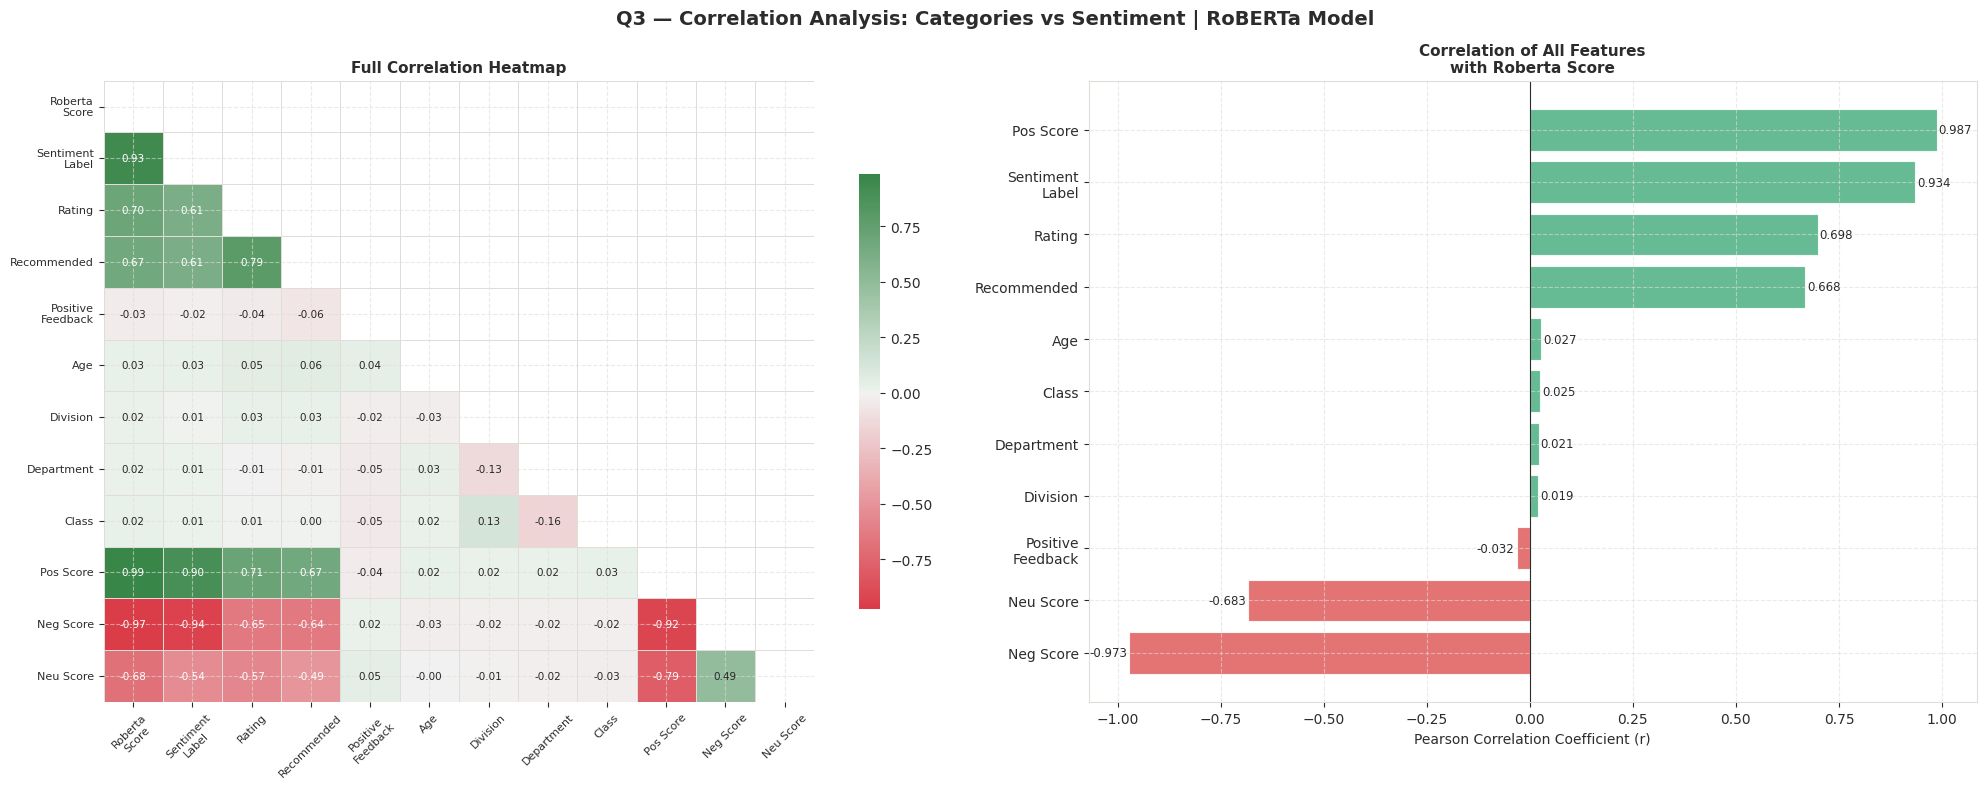

Fig 4 — Correlation Analysis


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor(BRAND_PALETTE['bg'])
fig.suptitle('Q3 — Correlation Analysis: Categories vs Sentiment | RoBERTa Model',
             fontsize=14, fontweight='bold', color=BRAND_PALETTE['text'])

# Left: Full Correlation Heatmap
ax = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide mirrored upper triangle
cmap = sns.diverging_palette(10, 133, as_cmap=True)     # Red = negative, Green = positive
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7.5},
            xticklabels=corr_labels, yticklabels=corr_labels,
            linewidths=0.5, linecolor=BRAND_PALETTE['grid'],
            ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Full Correlation Heatmap', fontweight='bold', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

# Right: Bar chart — each feature's correlation with Roberta Score
ax2 = axes[1]
ax2.set_facecolor(BRAND_PALETTE['bg'])
corr_labels_bar = [corr_labels[corr_cols.index(c)] for c in corr_with_target.index]
colors = [BRAND_PALETTE['Positive'] if v > 0 else BRAND_PALETTE['Negative']
          for v in corr_with_target.values]
bars = ax2.barh(corr_labels_bar, corr_with_target.values,
                color=colors, edgecolor='white', linewidth=0.8, alpha=0.85)
for bar, v in zip(bars, corr_with_target.values):
    x_pos = v + 0.005 if v >= 0 else v - 0.005
    ha = 'left' if v >= 0 else 'right'
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{v:.3f}', va='center', ha=ha, fontsize=8.5)
ax2.axvline(0, color=BRAND_PALETTE['text'], linewidth=0.8)
ax2.set_title('Correlation of All Features\nwith Roberta Score', fontweight='bold', fontsize=11)
ax2.set_xlabel('Pearson Correlation Coefficient (r)')

plt.tight_layout()
plt.savefig('fig4_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 4 — Correlation Analysis')

##Step 8 — Bonus Deep Dive: Cross-Analysis (Fig 5)

**What this does:**  
Four supplementary charts for the Tuesday discussion:
1. **Rating × Sentiment stacked bar** — does RoBERTa's labelling align with star ratings? (model sanity check)
2. **Violin plot by department** — spread of Roberta Scores per department, not just averages
3. **Age vs Roberta Score scatter** — does reviewer age affect sentiment tone?
4. **Class sorted bar** — all classes ranked by Roberta Score

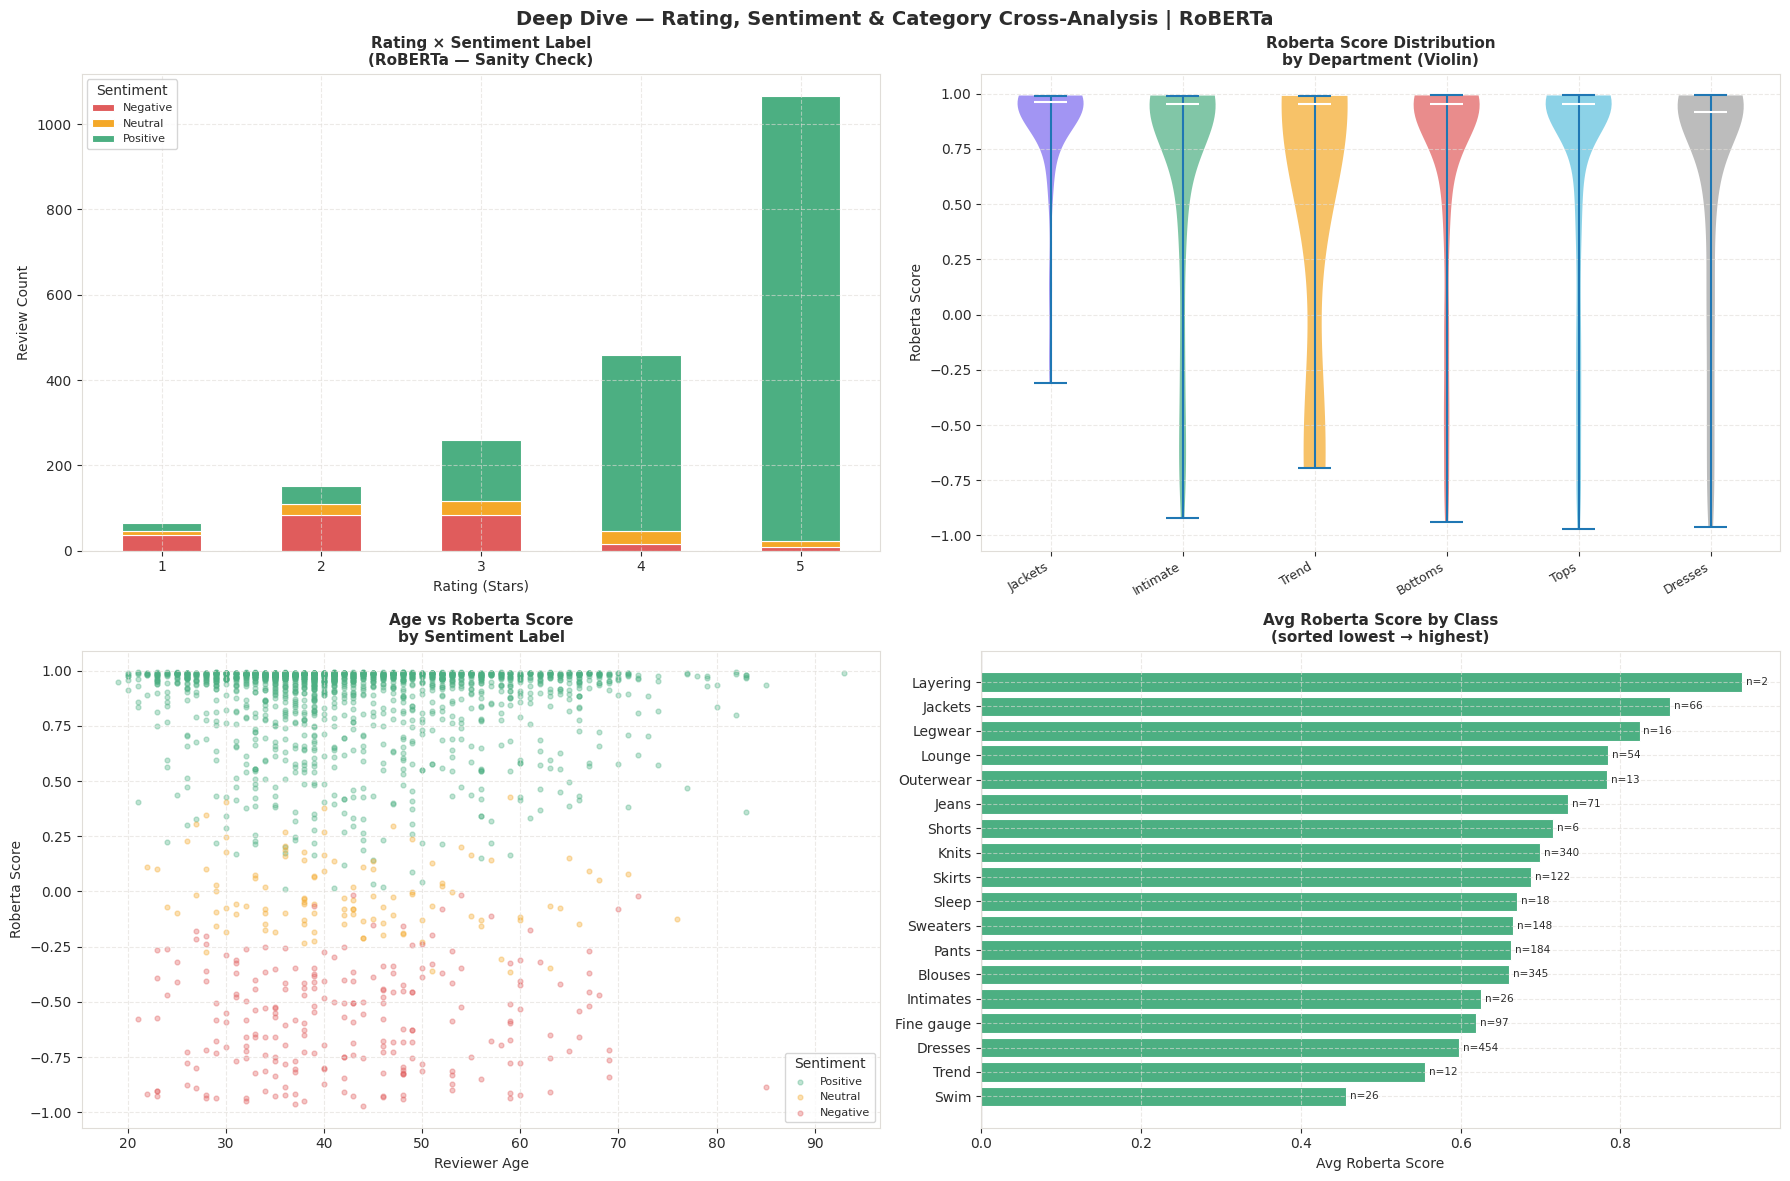

Fig 5 — Cross Analysis


In [56]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor(BRAND_PALETTE['bg'])
fig.suptitle('Deep Dive — Rating, Sentiment & Category Cross-Analysis | RoBERTa',
             fontsize=14, fontweight='bold', color=BRAND_PALETTE['text'])

sent_colors = [BRAND_PALETTE['Negative'], BRAND_PALETTE['Neutral'], BRAND_PALETTE['Positive']]

# ── Panel 1: Rating × Sentiment (stacked bar) ─────────────────
ax = axes[0, 0]
ax.set_facecolor(BRAND_PALETTE['bg'])
rt_sent = df.groupby(['Rating', 'Sentiment Label']).size().unstack(fill_value=0)
for label in ['Negative', 'Neutral', 'Positive']:
    if label not in rt_sent.columns:
        rt_sent[label] = 0
rt_sent = rt_sent[['Negative', 'Neutral', 'Positive']]
rt_sent.plot(kind='bar', stacked=True, ax=ax,
             color=sent_colors, edgecolor='white', linewidth=0.8)
ax.set_title('Rating × Sentiment Label\n(RoBERTa — Sanity Check)', fontweight='bold', fontsize=11)
ax.set_xlabel('Rating (Stars)')
ax.set_ylabel('Review Count')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Sentiment', fontsize=8)

# ── Panel 2: Violin Plot by Department ────────────────────────
ax = axes[0, 1]
ax.set_facecolor(BRAND_PALETTE['bg'])
dept_order = (df.dropna(subset=['Department Name'])
               .groupby('Department Name')['Roberta Score']
               .median().sort_values(ascending=False).index)
parts = ax.violinplot(
    [df[df['Department Name'] == d]['Roberta Score'].values for d in dept_order],
    positions=range(len(dept_order)),
    showmedians=True, showextrema=True
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(DEPT_COLORS[i % len(DEPT_COLORS)])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('white')
ax.set_xticks(range(len(dept_order)))
ax.set_xticklabels(dept_order, rotation=30, ha='right', fontsize=9)
ax.set_title('Roberta Score Distribution\nby Department (Violin)', fontweight='bold', fontsize=11)
ax.set_ylabel('Roberta Score')

# ── Panel 3: Age vs Roberta Score Scatter ─────────────────────
ax = axes[1, 0]
ax.set_facecolor(BRAND_PALETTE['bg'])
for label in ['Positive', 'Neutral', 'Negative']:
    sub = df[df['Sentiment Label'] == label]
    ax.scatter(sub['Age'], sub['Roberta Score'],
               c=BRAND_PALETTE[label], label=label, alpha=0.35, s=12)
ax.set_xlabel('Reviewer Age')
ax.set_ylabel('Roberta Score')
ax.set_title('Age vs Roberta Score\nby Sentiment Label', fontweight='bold', fontsize=11)
ax.legend(title='Sentiment', fontsize=8)

# ── Panel 4: Class Sorted Bar Chart ───────────────────────────
ax = axes[1, 1]
ax.set_facecolor(BRAND_PALETTE['bg'])
bar_colors_cls = [BRAND_PALETTE['Negative'] if v < 0 else BRAND_PALETTE['Positive']
                  for v in class_df['Avg_Score']]
ax.barh(class_df['Class Name'], class_df['Avg_Score'],
        color=bar_colors_cls, edgecolor='white', linewidth=0.8)
for i, (_, row) in enumerate(class_df.iterrows()):
    ax.text(row['Avg_Score'] + 0.005, i, f"n={row['Count']:.0f}",
            va='center', fontsize=7.5)
ax.axvline(0, color=BRAND_PALETTE['text'], linewidth=0.8)
ax.set_title('Avg Roberta Score by Class\n(sorted lowest → highest)', fontweight='bold', fontsize=11)
ax.set_xlabel('Avg Roberta Score')

plt.tight_layout()
plt.savefig('fig5_cross_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 5 — Cross Analysis')

## 📋 Step 9 — Key Findings Summary

In [57]:
print('=' * 60)
print('KEY FINDINGS SUMMARY — RoBERTa Model')
print('=' * 60)

print(f'\nSentiment breakdown (n=2,000):')
for label, count in df['Sentiment Label'].value_counts().items():
    print(f'  {label}: {count:,} ({count/len(df)*100:.1f}%)')

print(f'\nRoberta Score range: {df["Roberta Score"].min():.3f} to {df["Roberta Score"].max():.3f}')
print(f'Mean Roberta Score: {df["Roberta Score"].mean():.3f}')

print(f'\nQ1 — Products (min 5 reviews):')
print(f'  Most positive: Clothing ID {int(top_pos.iloc[0]["Clothing ID"])} '
      f'(avg={top_pos.iloc[0]["Avg_Score"]:.3f}, n={int(top_pos.iloc[0]["Review_Count"])})')
print(f'  Most negative: Clothing ID {int(top_neg.iloc[0]["Clothing ID"])} '
      f'(avg={top_neg.iloc[0]["Avg_Score"]:.3f}, n={int(top_neg.iloc[0]["Review_Count"])})')

print(f'\nQ2 — Division:')
print(f'  Most positive: {div_df.iloc[-1]["Division Name"]} (avg={div_df.iloc[-1]["Avg_Score"]:.3f})')
print(f'  Most negative: {div_df.iloc[0]["Division Name"]}  (avg={div_df.iloc[0]["Avg_Score"]:.3f})')

print(f'\nQ2 — Department:')
print(f'  Most positive: {dept_df.iloc[-1]["Department Name"]} (avg={dept_df.iloc[-1]["Avg_Score"]:.3f})')
print(f'  Most negative: {dept_df.iloc[0]["Department Name"]}  (avg={dept_df.iloc[0]["Avg_Score"]:.3f})')

print(f'\nQ2 — Class:')
print(f'  Most positive: {class_df.iloc[-1]["Class Name"]} (avg={class_df.iloc[-1]["Avg_Score"]:.3f})')
print(f'  Most negative: {class_df.iloc[0]["Class Name"]}  (avg={class_df.iloc[0]["Avg_Score"]:.3f})')

print(f'\nQ3 — Strongest correlations with Roberta Score:')
for col, val in corr_with_target.abs().sort_values(ascending=False).head(5).items():
    actual = corr_with_target[col]
    direction = '↑ positive relationship' if actual > 0 else '↓ negative relationship'
    print(f'  {col}: r = {actual:.3f}  ({direction})')

print('\n Analysis complete!')

KEY FINDINGS SUMMARY — RoBERTa Model

Sentiment breakdown (n=2,000):
  Positive: 1,658 (82.9%)
  Negative: 231 (11.6%)
  Neutral: 111 (5.5%)

Roberta Score range: -0.971 to 0.992
Mean Roberta Score: 0.665

Q1 — Products (min 5 reviews):
  Most positive: Clothing ID 745 (avg=0.977, n=5)
  Most negative: Clothing ID 946 (avg=-0.036, n=6)

Q2 — Division:
  Most positive: Initmates (avg=0.681)
  Most negative: General  (avg=0.656)

Q2 — Department:
  Most positive: Jackets (avg=0.849)
  Most negative: Trend  (avg=0.555)

Q2 — Class:
  Most positive: Layering (avg=0.952)
  Most negative: Swim  (avg=0.456)

Q3 — Strongest correlations with Roberta Score:
  Roberta Pos Score: r = 0.987  (↑ positive relationship)
  Roberta Neg Score: r = -0.973  (↓ negative relationship)
  Sentiment_Enc: r = 0.934  (↑ positive relationship)
  Rating: r = 0.698  (↑ positive relationship)
  Roberta Neu Score: r = -0.683  (↓ negative relationship)

 Analysis complete!
